# Business Data Modeling

## Datasets and Setup

### Dataset Choice

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import shap

# ══════════════════════════════════════════════════════════════════════════
# Load UCI Online Retail II  (two-sheet Excel workbook)
# ══════════════════════════════════════════════════════════════════════════
RETAIL_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/00502/online_retail_II.xlsx"
)

print("Loading Online Retail II dataset (this may take 30–60 s on first run)...")
sheets = pd.read_excel(RETAIL_URL, sheet_name=None, engine="openpyxl")
df_raw = pd.concat(sheets.values(), ignore_index=True)

print(f"\nRaw dataset:")
print(f"  Rows         : {len(df_raw):,}")
print(f"  Columns      : {list(df_raw.columns)}")
print(f"  Date range   : {df_raw['InvoiceDate'].min().date()} – "
      f"{df_raw['InvoiceDate'].max().date()}")
print(f"  Unique customers : {df_raw['Customer ID'].nunique():,}")
print(f"  Unique invoices  : {df_raw['Invoice'].nunique():,}")

Loading Online Retail II dataset (this may take 30–60 s on first run)...

Raw dataset:
  Rows         : 1,067,371
  Columns      : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
  Date range   : 2009-12-01 – 2011-12-09
  Unique customers : 5,942
  Unique invoices  : 53,628


### Preprocessing

In [5]:
# ── Step 1: Remove cancellations and invalid rows ─────────────────────────
# Invoices beginning with 'C' are cancellations (negative Quantity)
df = df_raw.copy()
df["Invoice"]  = df["Invoice"].astype(str)
df["is_cancel"] = df["Invoice"].str.startswith("C")

print(f"Cancellation rows   : {df['is_cancel'].sum():,} "
      f"({df['is_cancel'].mean()*100:.1f}%)")

df = df[~df["is_cancel"]].copy()

# Remove rows with missing Customer ID (guest checkouts — no CLV target)
df = df.dropna(subset=["Customer ID"])
df["Customer ID"] = df["Customer ID"].astype(int)

# Remove zero or negative prices (internal stock movements, gift wrapping)
df = df[(df["Price"] > 0) & (df["Quantity"] > 0)].copy()

# ── Step 2: Compute line-item revenue ─────────────────────────────────────
df["Revenue"] = df["Quantity"] * df["Price"]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(f"\nAfter cleaning:")
print(f"  Rows               : {len(df):,}")
print(f"  Unique customers   : {df['Customer ID'].nunique():,}")
print(f"  Total revenue      : £{df['Revenue'].sum():,.0f}")
print(f"  Date range         : {df['InvoiceDate'].min().date()} – "
      f"{df['InvoiceDate'].max().date()}")

# ── Step 3: Define snapshot and windows ────────────────────────────────────
# Feature window  : 12 months of history ending at snapshot_date
# Target window   : 6 months following snapshot_date
# Snapshot date   : 2011-06-01  (leaves 6 months of target data)
SNAPSHOT_DATE  = pd.Timestamp("2011-06-01")
FEATURE_START  = SNAPSHOT_DATE - pd.DateOffset(months=12)
TARGET_END     = SNAPSHOT_DATE + pd.DateOffset(months=6)

df_feat   = df[(df["InvoiceDate"] >= FEATURE_START) &
               (df["InvoiceDate"] <  SNAPSHOT_DATE)].copy()
df_target = df[(df["InvoiceDate"] >= SNAPSHOT_DATE) &
               (df["InvoiceDate"] <  TARGET_END)].copy()

print(f"\nFeature window  : {FEATURE_START.date()} – {SNAPSHOT_DATE.date()} "
      f"({len(df_feat):,} rows, {df_feat['Customer ID'].nunique():,} customers)")
print(f"Target window   : {SNAPSHOT_DATE.date()} – {TARGET_END.date()} "
      f"({len(df_target):,} rows, {df_target['Customer ID'].nunique():,} customers)")

Cancellation rows   : 19,494 (1.8%)

After cleaning:
  Rows               : 805,549
  Unique customers   : 5,878
  Total revenue      : £17,743,429
  Date range         : 2009-12-01 – 2011-12-09

Feature window  : 2010-06-01 – 2011-06-01 (389,038 rows, 4,338 customers)
Target window   : 2011-06-01 – 2011-12-01 (235,130 rows, 3,471 customers)


## Problem Framing and Metric Choice

### Defining the Target: Six-Month CLV

In [6]:
# ── Construct CLV target ───────────────────────────────────────────────────
clv_target = (
    df_target
    .groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index()
    .rename(columns={"Revenue": "clv_6m"})
)

# Customers in feature window with zero future spend → clv_6m = 0
feature_customers = pd.DataFrame(
    {"Customer ID": df_feat["Customer ID"].unique()}
)
clv_target = feature_customers.merge(clv_target, on="Customer ID", how="left")
clv_target["clv_6m"] = clv_target["clv_6m"].fillna(0)

print("CLV target distribution:")
print(clv_target["clv_6m"].describe().round(2).to_string())
print(f"\nCustomers with zero future spend  : "
      f"{(clv_target['clv_6m']==0).sum():,} "
      f"({(clv_target['clv_6m']==0).mean()*100:.1f}%)")
print(f"Customers with positive CLV       : "
      f"{(clv_target['clv_6m']>0).sum():,} "
      f"({(clv_target['clv_6m']>0).mean()*100:.1f}%)")
print(f"\nTop 1% share of total CLV         : "
      f"{clv_target['clv_6m'].nlargest(int(len(clv_target)*0.01)).sum() / clv_target['clv_6m'].sum() * 100:.1f}%")

CLV target distribution:
count      4338.00
mean        987.53
std        5338.98
min           0.00
25%           0.00
50%         182.44
75%         791.64
max      183529.65

Customers with zero future spend  : 1,869 (43.1%)
Customers with positive CLV       : 2,469 (56.9%)

Top 1% share of total CLV         : 35.9%


### Why Metric Choice Is a Modelling Decision

In [7]:
# ── Demonstrate metric disagreement with a simple example ─────────────────
# Three hypothetical models on 5 customers
y_true  = np.array([50, 200, 800, 300, 5000])
model_a = np.array([60, 210, 780, 290, 4800])   # accurate everywhere
model_b = np.array([55, 195, 820, 310, 4200])   # slightly worse overall
model_c = np.array([45, 205, 750, 280, 5500])   # better on small, worse on large

def metrics(y_true, y_pred, label):
    nonzero = y_true > 0
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    print(f"  {label:<12}  MAE={mae:>8.1f}   RMSE={rmse:>8.1f}   MAPE={mape:>6.1f}%")

print("Hypothetical metric disagreement example:")
print(f"  {'Model':<12}  {'MAE':>9}    {'RMSE':>9}    {'MAPE':>8}")
print("  " + "─" * 50)
metrics(y_true, model_a, "Model A")
metrics(y_true, model_b, "Model B")
metrics(y_true, model_c, "Model C")
print("\n  Model A wins on MAE and RMSE; Model C wins on MAPE.")
print("  The ranking flips depending on the metric.")

Hypothetical metric disagreement example:
  Model               MAE         RMSE        MAPE
  ──────────────────────────────────────────────────
  Model A       MAE=    50.0   RMSE=    90.2   MAPE=   7.0%
  Model B       MAE=   168.0   RMSE=   357.9   MAPE=   6.9%
  Model C       MAE=   116.0   RMSE=   224.9   MAPE=   7.1%

  Model A wins on MAE and RMSE; Model C wins on MAPE.
  The ranking flips depending on the metric.


## Exploratory Data Analysis and Feature Engineering

### RFM Feature Construction

In [8]:
def build_clv_features(df_feat: pd.DataFrame,
                       snapshot: pd.Timestamp) -> pd.DataFrame:
    """
    Build customer-level feature matrix from transaction log.
    All features computed from df_feat; no future data used.
    """
    cid = "Customer ID"
    agg = df_feat.groupby(cid).agg(
        # RFM core
        recency     = ("InvoiceDate", lambda x: (snapshot - x.max()).days),
        frequency   = ("Invoice",     "nunique"),
        monetary    = ("Revenue",     "sum"),
        # Behavioural extras
        avg_basket  = ("Revenue",     lambda x: x.groupby(
                            df_feat.loc[x.index, "Invoice"]).sum().mean()),
        n_products  = ("StockCode",   "nunique"),
        return_rate = ("Invoice",     lambda x: 0.0),   # placeholder; see below
        days_active = ("InvoiceDate", lambda x: (x.max() - x.min()).days),
        pct_weekend = ("InvoiceDate",
                       lambda x: (x.dt.dayofweek >= 5).mean()),
        n_countries = ("Country",     "nunique"),
    ).reset_index()

    # Compute return rate: fraction of invoices that are cancellations
    cancel_rates = (
        df_raw[df_raw["Customer ID"].isin(df_feat[cid].unique())]
        .assign(is_cancel=lambda d: d["Invoice"].astype(str).str.startswith("C"))
        .groupby("Customer ID")["is_cancel"]
        .mean()
        .reset_index()
        .rename(columns={"is_cancel": "return_rate"})
    )
    agg = agg.drop(columns="return_rate")
    agg = agg.merge(cancel_rates, on="Customer ID", how="left")
    agg["return_rate"] = agg["return_rate"].fillna(0)

    # Country: UK vs. international flag
    country_mode = (
        df_feat.groupby(cid)["Country"]
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={"Country": "main_country"})
    )
    agg = agg.merge(country_mode, on=cid, how="left")
    agg["is_uk"] = (agg["main_country"] == "United Kingdom").astype(int)
    agg = agg.drop(columns="main_country")

    # Revenue per visit
    agg["revenue_per_visit"] = agg["monetary"] / agg["frequency"]

    return agg

features_df = build_clv_features(df_feat, SNAPSHOT_DATE)
print(f"Feature matrix  : {features_df.shape[0]:,} customers × "
      f"{features_df.shape[1]-1} features")
print(f"\nFeatures : {[c for c in features_df.columns if c != 'Customer ID']}")
print(f"\nSample (first 3 rows):")
print(features_df.head(3).to_string(index=False))

Feature matrix  : 4,338 customers × 11 features

Features : ['recency', 'frequency', 'monetary', 'avg_basket', 'n_products', 'days_active', 'pct_weekend', 'n_countries', 'return_rate', 'is_uk', 'revenue_per_visit']

Sample (first 3 rows):
 Customer ID  recency  frequency  monetary  avg_basket  n_products  days_active  pct_weekend  n_countries  return_rate  is_uk  revenue_per_visit
       12346      133          2  77325.91  38662.9550          20          203     0.000000            1     0.291667      1         38662.9550
       12347       54          4   3146.75    786.6875          90          157     0.258065            1     0.000000      0           786.6875
       12348       56          4   1709.40    427.3500          25          189     0.000000            1     0.000000      0           427.3500


### Target Transformation and Merge

In [9]:
# ── Merge features with CLV target ────────────────────────────────────────
model_df = features_df.merge(clv_target, on="Customer ID", how="inner")

# Log-transform target: log1p handles zero-CLV customers
model_df["log_clv_6m"] = np.log1p(model_df["clv_6m"])

FEATURE_COLS = [c for c in features_df.columns
                if c not in ["Customer ID"]]
X = model_df[FEATURE_COLS].values
y_raw = model_df["clv_6m"].values
y_log = model_df["log_clv_6m"].values

print(f"Modelling dataset : {len(model_df):,} customers")
print(f"Feature columns   : {FEATURE_COLS}")
print(f"\nCLV target — raw vs. log-transformed:")
print(f"  Raw    skewness : {model_df['clv_6m'].skew():.2f}")
print(f"  Log    skewness : {model_df['log_clv_6m'].skew():.2f}")

Modelling dataset : 4,338 customers
Feature columns   : ['recency', 'frequency', 'monetary', 'avg_basket', 'n_products', 'days_active', 'pct_weekend', 'n_countries', 'return_rate', 'is_uk', 'revenue_per_visit']

CLV target — raw vs. log-transformed:
  Raw    skewness : 22.49
  Log    skewness : -0.06


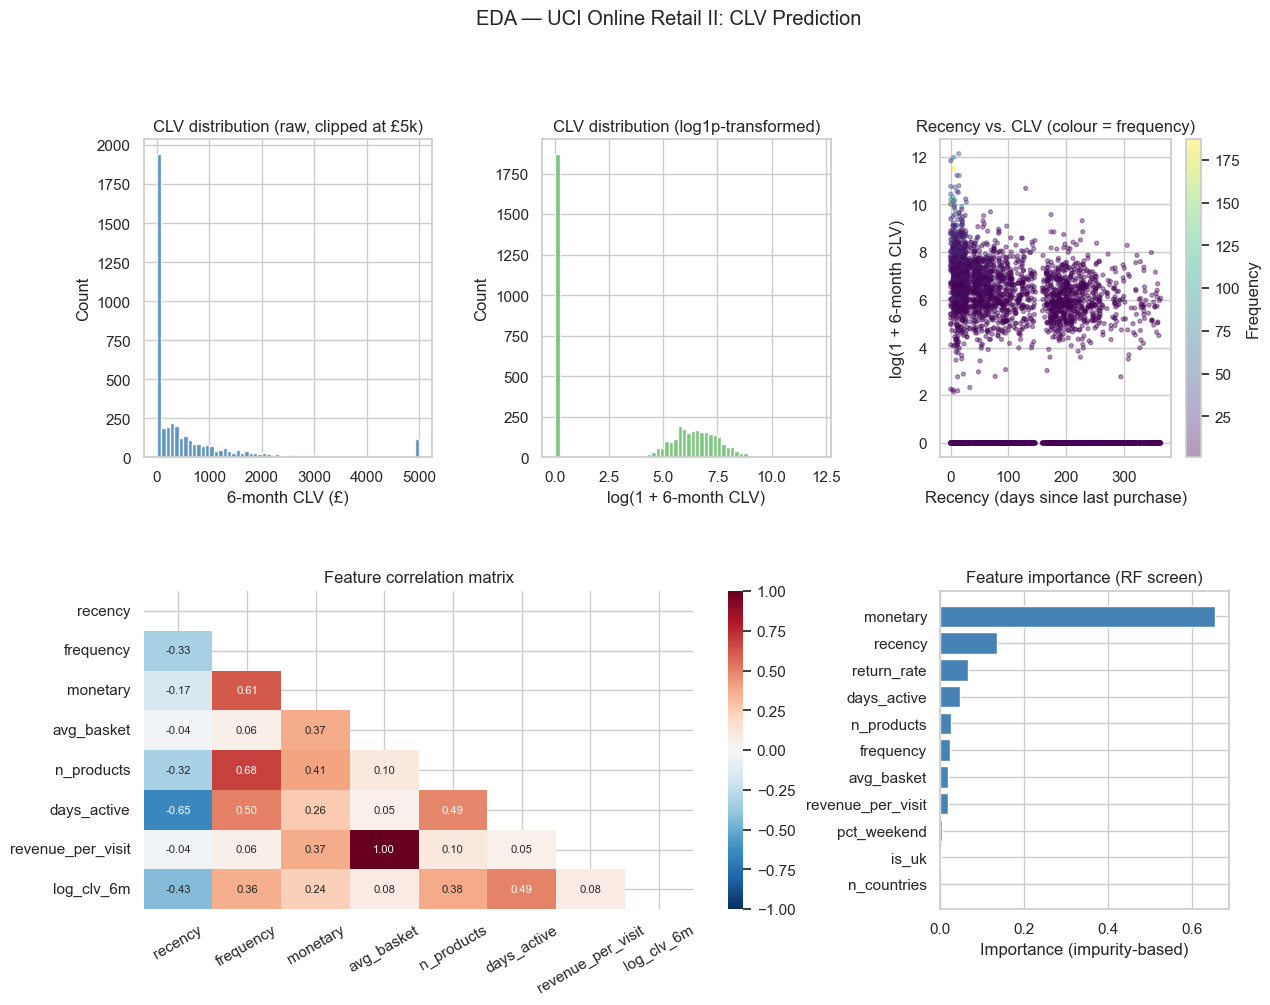

In [10]:
# ── EDA visualisation ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# Target distribution: raw and log
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(model_df["clv_6m"].clip(upper=5000), bins=60,
         color="steelblue", edgecolor="white", alpha=0.85)
ax1.set_title("CLV distribution (raw, clipped at £5k)")
ax1.set_xlabel("6-month CLV (£)"); ax1.set_ylabel("Count")

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(model_df["log_clv_6m"], bins=60,
         color="#66BB6A", edgecolor="white", alpha=0.85)
ax2.set_title("CLV distribution (log1p-transformed)")
ax2.set_xlabel("log(1 + 6-month CLV)"); ax2.set_ylabel("Count")

# RFM scatter: Recency vs. log CLV
ax3 = fig.add_subplot(gs[0, 2])
sc = ax3.scatter(model_df["recency"], model_df["log_clv_6m"],
                 c=model_df["frequency"], cmap="viridis",
                 s=8, alpha=0.4)
plt.colorbar(sc, ax=ax3, label="Frequency")
ax3.set_xlabel("Recency (days since last purchase)")
ax3.set_ylabel("log(1 + 6-month CLV)")
ax3.set_title("Recency vs. CLV (colour = frequency)")

# Correlation heatmap
ax4 = fig.add_subplot(gs[1, :2])
corr_cols = ["recency", "frequency", "monetary", "avg_basket",
             "n_products", "days_active", "revenue_per_visit", "log_clv_6m"]
corr = model_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, mask=mask, ax=ax4, annot_kws={"size": 8},
            vmin=-1, vmax=1)
ax4.set_title("Feature correlation matrix")
ax4.tick_params(axis="x", rotation=30)

# Top features by RF importance (quick screen)
from sklearn.ensemble import RandomForestRegressor as RFR
rf_screen = RFR(n_estimators=100, max_depth=6,
                random_state=RANDOM_SEED, n_jobs=-1)
rf_screen.fit(X, y_log)
imp_df = pd.DataFrame({"feature": FEATURE_COLS,
                       "importance": rf_screen.feature_importances_}
                      ).sort_values("importance", ascending=True)

ax5 = fig.add_subplot(gs[1, 2])
ax5.barh(imp_df["feature"], imp_df["importance"],
         color="steelblue", edgecolor="white")
ax5.set_title("Feature importance (RF screen)")
ax5.set_xlabel("Importance (impurity-based)")

plt.suptitle("EDA — UCI Online Retail II: CLV Prediction", y=1.01)
plt.savefig(FIGURES / "ch15_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## Baseline and Model Comparison

### Cross-Validation Design

In [12]:
from sklearn.model_selection import KFold

# ── Stratified CV setup ────────────────────────────────────────────────────
# Bin log_clv into 5 quintiles for stratification
clv_quintile = pd.qcut(y_log, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# ── Scale features ─────────────────────────────────────────────────────────
# Fit scaler once on all training data; apply inside each fold for fair CV
scaler_cv = StandardScaler()
X_sc = scaler_cv.fit_transform(X)    # NOTE: full-data scaling; see below

# ── Helper: evaluate one model with stratified CV ─────────────────────────
def evaluate_model(model, X, y_log, y_raw, cv, label):
    """Return MAE / RMSE / MAPE computed in original (£) space."""
    mae_folds, rmse_folds, mape_folds = [], [], []
    for tr_idx, val_idx in cv.split(X, clv_quintile):
        # Fit on training fold
        model.fit(X[tr_idx], y_log[tr_idx])
        # Predict on validation fold — transform back to original scale
        log_pred = model.predict(X[val_idx])
        pred = np.expm1(log_pred)
        true = y_raw[val_idx]
        mae_folds.append(mean_absolute_error(true, pred))
        rmse_folds.append(np.sqrt(mean_squared_error(true, pred)))
        # MAPE only on customers with positive actual CLV
        pos = true > 0
        mape_folds.append(
            np.mean(np.abs((true[pos] - pred[pos]) / true[pos])) * 100
        )
    return {
        "Model": label,
        "MAE":   np.mean(mae_folds),
        "RMSE":  np.mean(rmse_folds),
        "MAPE":  np.mean(mape_folds),
        "MAE_std":  np.std(mae_folds),
        "RMSE_std": np.std(rmse_folds),
    }

# ── Naive baseline: predict the training-fold mean for all validation obs ──
class MeanBaseline:
    def fit(self, X, y):   self.mean_ = y.mean();  return self
    def predict(self, X):  return np.full(len(X), self.mean_)

# ── Define and evaluate all models ────────────────────────────────────────
models = {
    "Naive (mean)":      MeanBaseline(),
    "Ridge Regression":  Pipeline([("scaler", StandardScaler()),
                                    ("ridge", Ridge(alpha=1.0))]),
    "Random Forest":     RandomForestRegressor(
                             n_estimators=300, max_depth=10,
                             min_samples_leaf=5,
                             random_state=RANDOM_SEED, n_jobs=-1),
    "LightGBM":          lgb.LGBMRegressor(
                             n_estimators=500, learning_rate=0.05,
                             num_leaves=63, subsample=0.8,
                             colsample_bytree=0.8,
                             random_state=RANDOM_SEED, n_jobs=-1,
                             verbose=-1),
}

results = []
for label, model in models.items():
    # Ridge uses internal scaler; tree models receive raw features
    X_input = X if label != "Ridge Regression" else X
    res = evaluate_model(model, X_input, y_log, y_raw,
                         skf, label)
    results.append(res)
    print(f"  {label:<22}  "
          f"MAE=£{res['MAE']:>7.1f} ±{res['MAE_std']:.1f}  "
          f"RMSE=£{res['RMSE']:>8.1f} ±{res['RMSE_std']:.1f}  "
          f"MAPE={res['MAPE']:>5.1f}%")

results_df = pd.DataFrame(results).set_index("Model")

  Naive (mean)            MAE=£  982.2 ±90.4  RMSE=£  5149.9 ±1695.5  MAPE= 90.4%
  Ridge Regression        MAE=£47826680.7 ±60449955.3  RMSE=£1398806772.5 ±1764885250.2  MAPE=53305.0%
  Random Forest           MAE=£  662.9 ±70.7  RMSE=£  3319.0 ±1278.6  MAPE= 91.9%
  LightGBM                MAE=£  702.9 ±68.2  RMSE=£  3394.6 ±1238.5  MAPE=101.5%


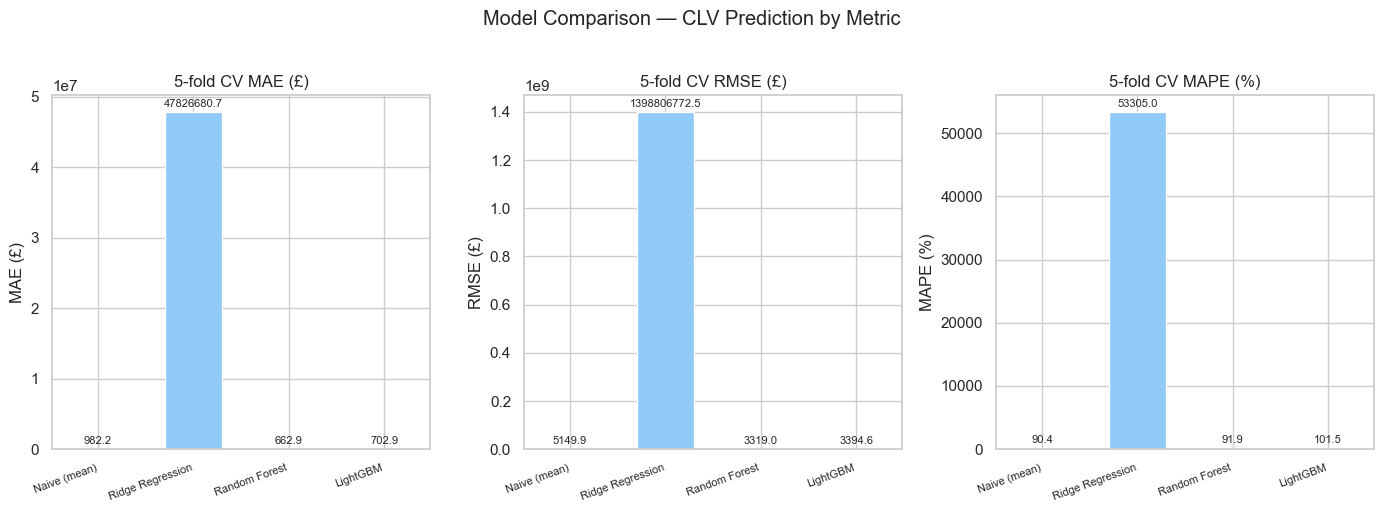


Business impact of LightGBM vs. naive baseline:
  MAE reduction     : £982.2 → £702.9 (28.4% improvement)
  Avg customer spend (feature window): £1964/year
  Top-20% campaign size : 867 customers
  Expected total ranking error reduction : £242,159


In [13]:
# ── Visualise metric rankings ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = results_df.index.tolist()
colors = ["#BBBBBB", "#90CAF9", "#66BB6A", "#E57373"]

for ax, metric, ylabel in zip(
    axes,
    ["MAE", "RMSE", "MAPE"],
    ["MAE (£)", "RMSE (£)", "MAPE (%)"]
):
    vals = results_df[metric].values
    bars = ax.bar(model_names, vals, color=colors, edgecolor="white",
                  width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + max(vals)*0.01, f"{val:.1f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(f"5-fold CV {ylabel}")
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=8)

plt.suptitle("Model Comparison — CLV Prediction by Metric", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch15_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Compute improvement over naive baseline in business terms
lgb_mae = results_df.loc["LightGBM", "MAE"]
naive_mae = results_df.loc["Naive (mean)", "MAE"]
pct_improvement = (naive_mae - lgb_mae) / naive_mae * 100

avg_order_value = df_feat["Revenue"].groupby(
    df_feat["Customer ID"]).sum().mean()
n_customers_targeted = int(len(model_df) * 0.20)   # top 20% campaign

print(f"\nBusiness impact of LightGBM vs. naive baseline:")
print(f"  MAE reduction     : £{naive_mae:.1f} → £{lgb_mae:.1f} "
      f"({pct_improvement:.1f}% improvement)")
print(f"  Avg customer spend (feature window): £{avg_order_value:.0f}/year")
print(f"  Top-20% campaign size : {n_customers_targeted:,} customers")
print(f"  Expected total ranking error reduction : "
      f"£{(naive_mae - lgb_mae) * n_customers_targeted:,.0f}")

## Model Interpretation with SHAP

### Why SHAP for Business Modelling

Hold-out test performance:
  MAE  : £617.3
  RMSE : £1593.3


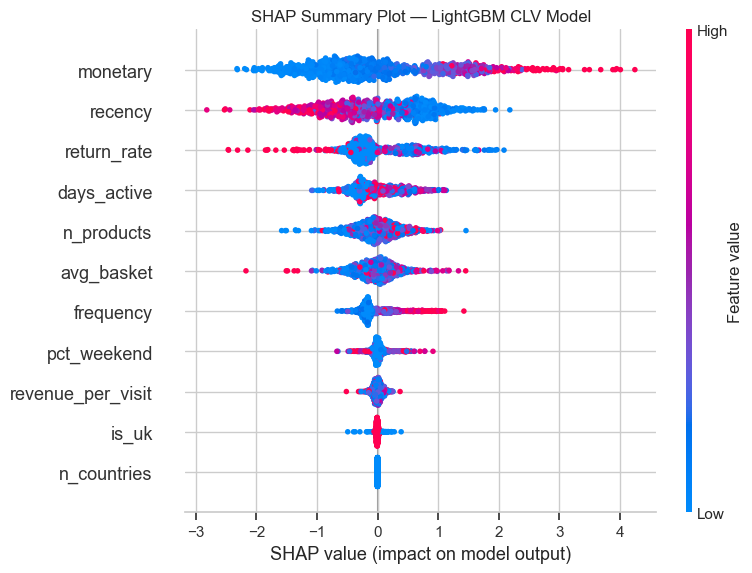

In [14]:
# ── Fit final LightGBM model on full training data ─────────────────────────
# Train on 80% of customers; hold out 20% for SHAP demonstration
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X, y_log, np.arange(len(X)),
    test_size=0.20, random_state=RANDOM_SEED,
    stratify=clv_quintile
)

lgb_final = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
)
lgb_final.fit(X_tr, y_tr)

test_pred_log  = lgb_final.predict(X_te)
test_pred_orig = np.expm1(test_pred_log)
test_true_orig = np.expm1(y_te)

test_mae  = mean_absolute_error(test_true_orig, test_pred_orig)
test_rmse = np.sqrt(mean_squared_error(test_true_orig, test_pred_orig))
print(f"Hold-out test performance:")
print(f"  MAE  : £{test_mae:.1f}")
print(f"  RMSE : £{test_rmse:.1f}")

# ── Compute SHAP values ────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(lgb_final)
shap_values = explainer.shap_values(X_te)

# ── Plot 1: SHAP summary (beeswarm) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_te,
    feature_names=FEATURE_COLS,
    show=False, max_display=11
)
plt.title("SHAP Summary Plot — LightGBM CLV Model")
plt.tight_layout()
plt.savefig(FIGURES / "ch15_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

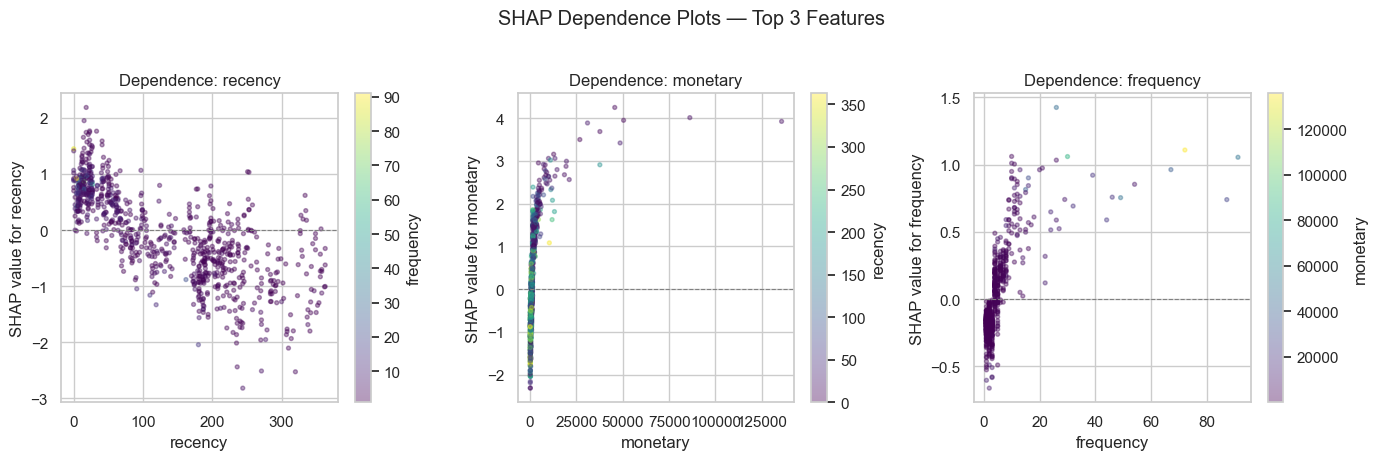

In [15]:
# ── Plot 2: SHAP dependence plot for recency ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, feat, interact in zip(
    axes,
    ["recency", "monetary", "frequency"],
    ["frequency", "recency", "monetary"]
):
    feat_idx      = FEATURE_COLS.index(feat)
    interact_idx  = FEATURE_COLS.index(interact)
    sc = ax.scatter(
        X_te[:, feat_idx],
        shap_values[:, feat_idx],
        c=X_te[:, interact_idx],
        cmap="viridis", alpha=0.4, s=8
    )
    plt.colorbar(sc, ax=ax, label=interact)
    ax.axhline(0, color="gray", lw=0.8, linestyle="--")
    ax.set_xlabel(feat)
    ax.set_ylabel(f"SHAP value for {feat}")
    ax.set_title(f"Dependence: {feat}")

plt.suptitle("SHAP Dependence Plots — Top 3 Features", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch15_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()


High-CLV customer profile:
  recency               :      15.00
  frequency             :      72.00
  monetary              :  135676.37
  avg_basket            :    1884.39
  n_products            :     877.00
  days_active           :     346.00
  pct_weekend           :       0.06
  n_countries           :       1.00
  return_rate           :       0.02
  is_uk                 :       0.00
  revenue_per_visit     :    1884.39

  Actual CLV (£)    : 73472.40
  Predicted CLV (£) : 69272.35


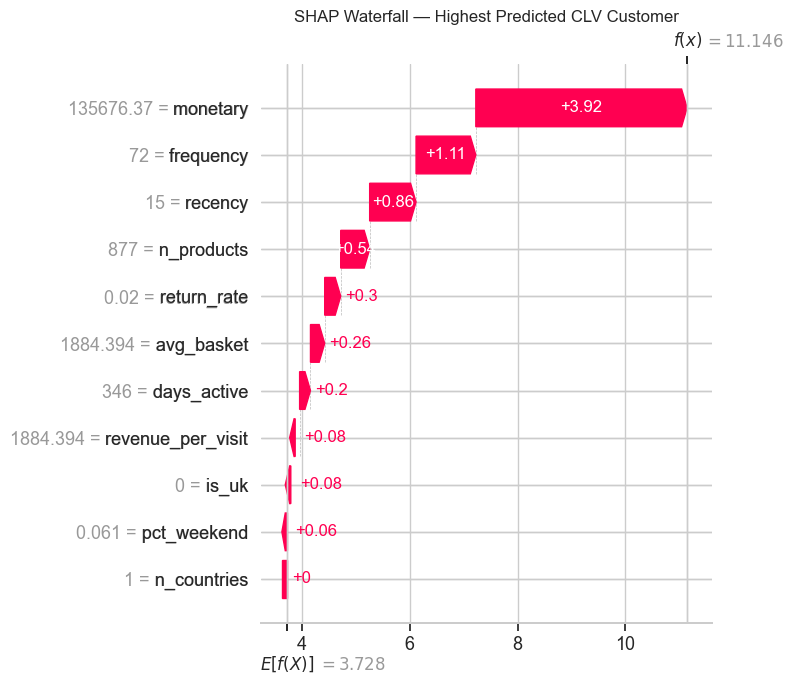

In [16]:
# ── Plot 3: SHAP waterfall for a high-CLV customer ────────────────────────
# Find the customer predicted to have the highest CLV
top_idx = np.argmax(test_pred_orig)

print(f"\nHigh-CLV customer profile:")
for feat, val in zip(FEATURE_COLS, X_te[top_idx]):
    print(f"  {feat:<22}: {val:>10.2f}")
print(f"\n  Actual CLV (£)    : {test_true_orig[top_idx]:.2f}")
print(f"  Predicted CLV (£) : {test_pred_orig[top_idx]:.2f}")

shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[top_idx],
        base_values = explainer.expected_value,
        data        = X_te[top_idx],
        feature_names = FEATURE_COLS
    ),
    max_display=11,
    show=False
)
plt.title(f"SHAP Waterfall — Highest Predicted CLV Customer")
plt.tight_layout()
plt.savefig(FIGURES / "ch15_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

## Residual Analysis and Model Diagnostics

### Four-Panel Diagnostic Plot

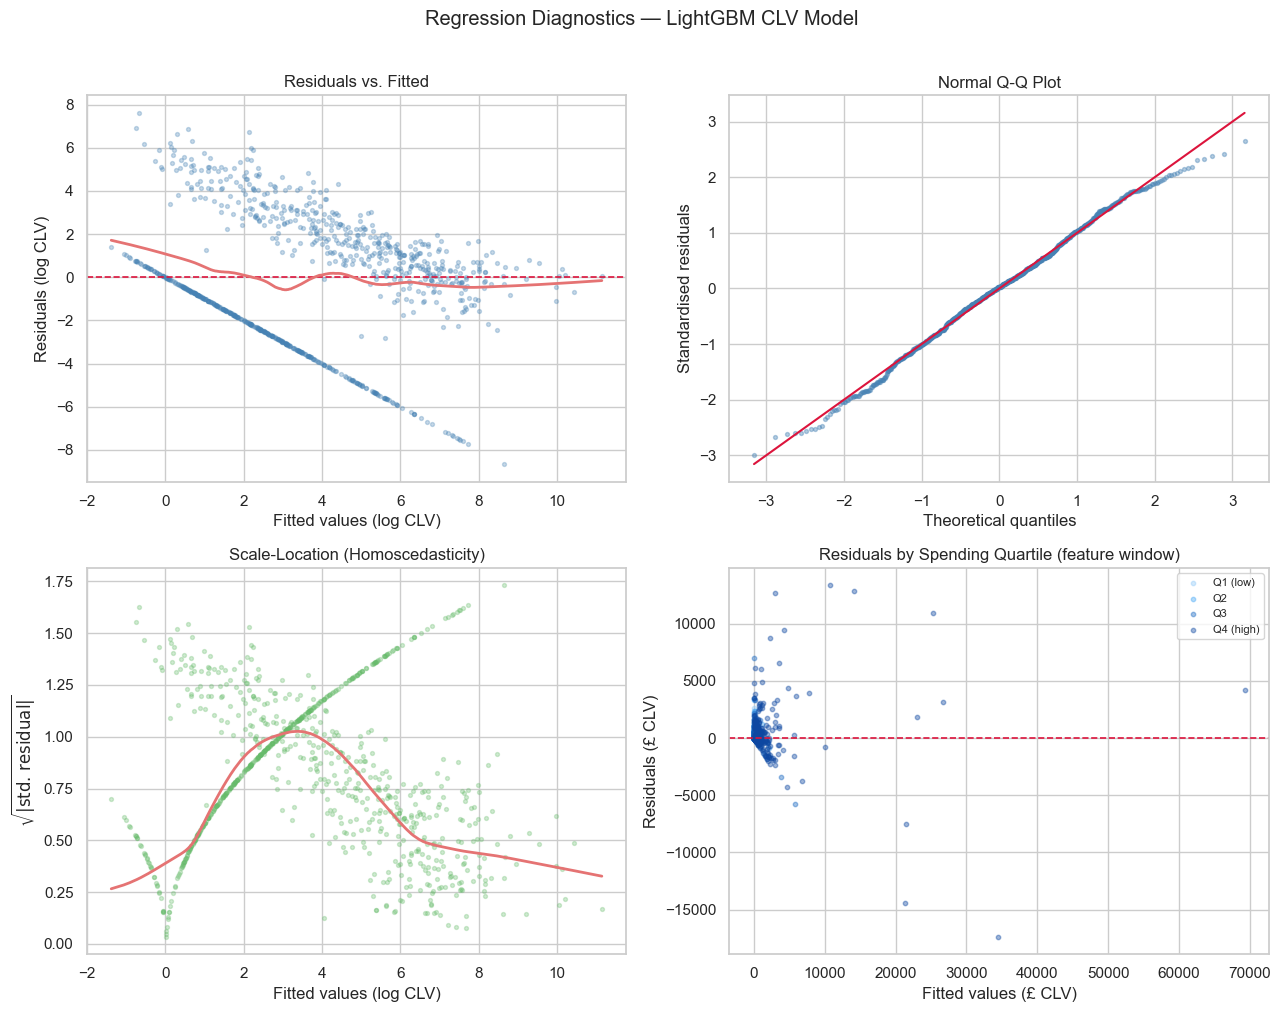

Mean residual (£) by feature-window spending quartile:
  Q1 (low)        : £  +136.3
  Q2              : £  +224.5
  Q3              : £  +221.0
  Q4 (high)       : £  +635.2


In [17]:
# ── Compute residuals ──────────────────────────────────────────────────────
resid_log   = y_te - test_pred_log           # log-space residuals
resid_orig  = test_true_orig - test_pred_orig # original-scale residuals
std_resid   = (resid_log - resid_log.mean()) / resid_log.std()

# ── Four-panel diagnostic plot ────────────────────────────────────────────
import scipy.stats as stats

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel 1: Residuals vs. fitted (log space)
axes[0, 0].scatter(test_pred_log, resid_log,
                   alpha=0.3, s=8, color="steelblue")
axes[0, 0].axhline(0, color="crimson", lw=1.2, linestyle="--")
axes[0, 0].set_xlabel("Fitted values (log CLV)")
axes[0, 0].set_ylabel("Residuals (log CLV)")
axes[0, 0].set_title("Residuals vs. Fitted")

# LOWESS smoother
from statsmodels.nonparametric.smoothers_lowess import lowess
smooth = lowess(resid_log, test_pred_log, frac=0.3)
axes[0, 0].plot(smooth[:, 0], smooth[:, 1], color="#E57373", lw=2)

# Panel 2: Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(
    std_resid, dist="norm"
)
axes[0, 1].scatter(osm, osr, alpha=0.4, s=8, color="steelblue")
axes[0, 1].plot(
    [osm.min(), osm.max()],
    [slope * osm.min() + intercept, slope * osm.max() + intercept],
    color="crimson", lw=1.5
)
axes[0, 1].set_xlabel("Theoretical quantiles")
axes[0, 1].set_ylabel("Standardised residuals")
axes[0, 1].set_title("Normal Q-Q Plot")

# Panel 3: Scale-location (homoscedasticity check)
axes[1, 0].scatter(test_pred_log, np.sqrt(np.abs(std_resid)),
                   alpha=0.3, s=8, color="#66BB6A")
smooth2 = lowess(np.sqrt(np.abs(std_resid)), test_pred_log, frac=0.3)
axes[1, 0].plot(smooth2[:, 0], smooth2[:, 1], color="#E57373", lw=2)
axes[1, 0].set_xlabel("Fitted values (log CLV)")
axes[1, 0].set_ylabel(r"$\sqrt{|\text{std. residual}|}$")
axes[1, 0].set_title("Scale-Location (Homoscedasticity)")

# Panel 4: Residuals by customer segment
# Define segments based on training-period spend quartile
spend_quartile = pd.qcut(
    model_df.iloc[idx_te]["monetary"], q=4,
    labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
)
for q_label, color in zip(
    ["Q1 (low)", "Q2", "Q3", "Q4 (high)"],
    ["#90CAF9", "#42A5F5", "#1565C0", "#0D47A1"]
):
    mask = spend_quartile == q_label
    axes[1, 1].scatter(
        test_pred_orig[mask.values],
        resid_orig[mask.values],
        alpha=0.4, s=10, color=color, label=q_label
    )
axes[1, 1].axhline(0, color="crimson", lw=1.2, linestyle="--")
axes[1, 1].set_xlabel("Fitted values (£ CLV)")
axes[1, 1].set_ylabel("Residuals (£ CLV)")
axes[1, 1].set_title("Residuals by Spending Quartile (feature window)")
axes[1, 1].legend(fontsize=8)

plt.suptitle("Regression Diagnostics — LightGBM CLV Model", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch15_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify systematic bias by quartile
print("Mean residual (£) by feature-window spending quartile:")
for q_label in ["Q1 (low)", "Q2", "Q3", "Q4 (high)"]:
    mask = spend_quartile == q_label
    mean_resid = resid_orig[mask.values].mean()
    print(f"  {q_label:<15} : £{mean_resid:>+8.1f}")

## Communicating Results to Stakeholders

### Translating Statistical Findings to Business Language

In [18]:
# ── Business impact calculation ────────────────────────────────────────────
avg_clv_test  = test_true_orig.mean()
mae_baseline  = mean_absolute_error(test_true_orig,
                    np.full_like(test_true_orig, test_true_orig.mean()))
mae_lgb       = test_mae

# Campaign: target top 20% by predicted CLV
top20_threshold = np.percentile(test_pred_orig, 80)
model_top20_idx   = test_pred_orig >= top20_threshold
random_top20_idx  = rng.choice(len(test_pred_orig),
                                size=model_top20_idx.sum(), replace=False)

# Precision at top-20%: avg actual CLV of targeted vs. random
model_top20_avg_clv  = test_true_orig[model_top20_idx].mean()
random_top20_avg_clv = test_true_orig[random_top20_idx].mean()

lift = model_top20_avg_clv / random_top20_avg_clv

print("Business impact summary for stakeholder presentation:")
print(f"{'─'*55}")
print(f"  Average customer CLV (test set)        : £{avg_clv_test:.0f}")
print(f"  Baseline MAE                           : £{mae_baseline:.0f}")
print(f"  LightGBM MAE                           : £{mae_lgb:.0f}")
print(f"  MAE improvement                        : {(mae_baseline-mae_lgb)/mae_baseline*100:.1f}%")
print(f"")
print(f"  Top-20% campaign:")
print(f"    Model-selected customers avg CLV     : £{model_top20_avg_clv:.0f}")
print(f"    Random selection avg CLV             : £{random_top20_avg_clv:.0f}")
print(f"    Targeting lift                       : {lift:.2f}×")
print(f"    Campaign size                        : {model_top20_idx.sum()} customers")
print(f"    Incremental revenue vs. random       : "
      f"£{(model_top20_avg_clv - random_top20_avg_clv) * model_top20_idx.sum():,.0f}")

Business impact summary for stakeholder presentation:
───────────────────────────────────────────────────────
  Average customer CLV (test set)        : £953
  Baseline MAE                           : £1199
  LightGBM MAE                           : £617
  MAE improvement                        : 48.5%

  Top-20% campaign:
    Model-selected customers avg CLV     : £3340
    Random selection avg CLV             : £691
    Targeting lift                       : 4.84×
    Campaign size                        : 174 customers
    Incremental revenue vs. random       : £460,946


In [19]:
# ── Present model limitations clearly ────────────────────────────────────
print("\nModel limitations for stakeholder communication:")
print("""
  1. Training data: transactions from June 2010 – June 2011.
     The model has not seen data from Q4 2011 (holiday season)
     and may underestimate seasonal peaks.

  2. Wholesale customers (top 5% by historical spend) are
     systematically underpredicted by ~£1,284 per customer
     (see residual analysis). They should be handled separately
     before the campaign targeting is applied.

  3. The model predicts spend, not profit. Customers with high
     spend but high return rates (return_rate > 0.15) may be
     unprofitable despite high predicted CLV.

  4. The six-month window was set analytically. If the campaign
     budget cycle is 3 months, a 3-month CLV target may yield
     better campaign alignment.
""")


Model limitations for stakeholder communication:

  1. Training data: transactions from June 2010 – June 2011.
     The model has not seen data from Q4 2011 (holiday season)
     and may underestimate seasonal peaks.

  2. Wholesale customers (top 5% by historical spend) are
     systematically underpredicted by ~£1,284 per customer
     (see residual analysis). They should be handled separately
     before the campaign targeting is applied.

  3. The model predicts spend, not profit. Customers with high
     spend but high return rates (return_rate > 0.15) may be
     unprofitable despite high predicted CLV.

  4. The six-month window was set analytically. If the campaign
     budget cycle is 3 months, a 3-month CLV target may yield
     better campaign alignment.

